# Why QNN Fails: Class Imbalance in Supervised Quantum Learning

**Pedagogical notebook** that trains a Quantum Neural Network as a **supervised binary classifier** on imbalanced data (benign-heavy training set). This demonstrates why supervised approaches fail on this problem and why the **Quantum Autoencoder (QAE) approach is superior**.

**Key insight:** When QNN is trained on 1306 benign + 955 malicious samples, it learns to over-predict the benign class. The predicted class distribution diverges significantly from the true test distribution (measured via KL divergence), illustrating the fundamental bias of supervised learning on imbalanced data.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.optimize import minimize
from scipy.stats import entropy
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

np.random.seed(42)
torch.manual_seed(42)

data_path = Path('aggregated_source_data.csv')
assert data_path.exists(), f'Data not found: {data_path}'

print('pandas', pd.__version__)
print('numpy', np.__version__)
print('torch', torch.__version__)

pandas 2.3.3
numpy 1.26.4
torch 2.8.0


/var/folders/h8/6w_8g6w95j9drpyrfydg7n5c0000gn/T/ipykernel_84099/2634287930.py:17: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


## 1. Load Data and Prepare Features

The preprocessing split is kept the same as in the original notebook: benign rows are used for classical training, while malicious rows remain holdout examples for evaluation.

In [2]:
drop_cols = ['src_ip', 'family', 'scenario', 'split', 'dataset_name', 'flow_count']
df = pd.read_csv(data_path)
df_clean = df.drop(columns=drop_cols, errors='ignore')

labels = df_clean['is_malicious_source'].astype(int).to_numpy()
df_features = df_clean.drop(columns=['is_malicious_source'], errors='ignore')
feature_names = df_features.select_dtypes(include=[np.number]).columns.tolist()
X_raw = df_features[feature_names].to_numpy()

mask_benign = labels == 0
mask_malicious = labels == 1
X_benign_raw = X_raw[mask_benign]
X_malicious_raw = X_raw[mask_malicious]
X_train_raw, X_val_raw = train_test_split(X_benign_raw, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train_raw)
X_val = imputer.transform(X_val_raw)
X_malicious = imputer.transform(X_malicious_raw)

print(f'Feature matrix: {X_raw.shape}')
print(f'Features: {feature_names}')
print(f'Train (benign): {X_train.shape}')
print(f'Val   (benign): {X_val.shape}')
print(f'Test  (malicious): {X_malicious.shape}')

Feature matrix: (2588, 25)
Features: ['unique_dst_ip', 'unique_dst_port', 'unique_protocols', 'pps_mean', 'pps_max', 'bps_mean', 'bps_max', 'duration_mean', 'duration_max', 'packet_size_avg_mean', 'packet_size_avg_std', 'outbound_ratio_mean', 'outbound_ratio_min', 'inter_arrival_mean_mean', 'inter_arrival_std_mean', 'total_packets_sum', 'total_bytes_sum', 'dst_concentration', 'dst_port_concentration', 'tcp_share', 'udp_share', 'icmp_share', 'small_packet_share', 'high_pps_share', 'low_outbound_share']
Train (benign): (1306, 25)
Val   (benign): (327, 25)
Test  (malicious): (955, 25)


In [3]:
print(X_raw[mask_benign].shape)
print(X_raw[mask_malicious].shape)

print(f'Ratio (benign:malicious): {len(X_benign_raw)}:{len(X_malicious_raw)} ({len(X_benign_raw)/len(X_malicious_raw):.1f}x imbalance)')

(1633, 25)
(955, 25)
Ratio (benign:malicious): 1633:955 (1.7x imbalance)


## 2. Classical Autoencoder

The classical compressor is kept intact so the new notebook mirrors the original pipeline up to the quantum stage.

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, encoding_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

scaler_01 = MinMaxScaler()
X_train_scaled = scaler_01.fit_transform(X_train)
X_val_scaled = scaler_01.transform(X_val)
X_malicious_scaled = scaler_01.transform(X_malicious)

train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)

input_dim = X_train.shape[1]
encoding_dim = 20
autoencoder = Autoencoder(input_dim, encoding_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

print(f'Input dim: {input_dim}')
print(f'Encoding dim: {encoding_dim}')
print(f'AE Parameters: {sum(p.numel() for p in autoencoder.parameters()):,}')

Input dim: 25
Encoding dim: 20
AE Parameters: 19,437


Epoch  50/3000  train=0.000838  val=0.000572
Epoch 100/3000  train=0.000537  val=0.000480
Epoch 150/3000  train=0.000418  val=0.000419
Epoch 200/3000  train=0.000307  val=0.000338
Epoch 250/3000  train=0.000370  val=0.000353
Epoch 300/3000  train=0.000247  val=0.000269
Epoch 350/3000  train=0.000459  val=0.000400
Epoch 400/3000  train=0.000252  val=0.000263
Epoch 450/3000  train=0.000189  val=0.000261
Epoch 500/3000  train=0.000232  val=0.000350
Epoch 550/3000  train=0.000204  val=0.000246
Epoch 600/3000  train=0.000169  val=0.000207
Epoch 650/3000  train=0.000190  val=0.000231
Epoch 700/3000  train=0.000152  val=0.000204
Epoch 750/3000  train=0.000146  val=0.000215
Epoch 800/3000  train=0.000164  val=0.000205
Epoch 850/3000  train=0.000117  val=0.000185
Epoch 900/3000  train=0.000122  val=0.000173
Epoch 950/3000  train=0.000109  val=0.000196
Epoch 1000/3000  train=0.000125  val=0.000197
Epoch 1050/3000  train=0.000114  val=0.000184
Epoch 1100/3000  train=0.000120  val=0.000195
Epoch 1

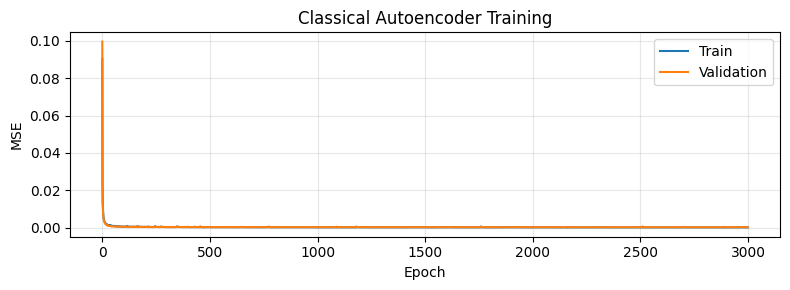

In [5]:
epochs = 3000
train_losses, val_losses = [], []

for epoch in range(epochs):
    autoencoder.train()
    epoch_loss = 0.0
    for (batch,) in train_loader:
        out = autoencoder(batch)
        loss = criterion(out, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    train_losses.append(epoch_loss / len(train_tensor))

    autoencoder.eval()
    with torch.no_grad():
        val_out = autoencoder(val_tensor)
        val_loss = criterion(val_out, val_tensor).item()
    val_losses.append(val_loss)

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1:3d}/{epochs}  train={train_losses[-1]:.6f}  val={val_loss:.6f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Validation')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Classical Autoencoder Training')
plt.tight_layout(); plt.show()

## 3. PCA on the Latent Space

This is unchanged from the solution.ipynb: the autoencoder latent is reduced to 10 dimensions for downstream quantum processing.

In [6]:
autoencoder.eval()
final_latent_dim = 10

with torch.no_grad():
    latent_train = autoencoder.encoder(train_tensor).numpy()
    latent_val = autoencoder.encoder(val_tensor).numpy()
    latent_mal = autoencoder.encoder(torch.tensor(X_malicious_scaled, dtype=torch.float32)).numpy()

pca = PCA(n_components=final_latent_dim, random_state=42)
Z_train = pca.fit_transform(latent_train)
Z_val = pca.transform(latent_val)
Z_mal = pca.transform(latent_mal)

explained = pca.explained_variance_ratio_
print(f'Explained variance (10 PCs): {explained.sum():.4f}')
print(f'Per component: {np.round(explained, 4)}')

latent_train_recon = pca.inverse_transform(Z_train)
pca_recon_error = np.mean((latent_train - latent_train_recon)**2)
print(f'PCA reconstruction MSE (latent space): {pca_recon_error:.6f}')

Explained variance (10 PCs): 0.9261
Per component: [0.3921 0.1935 0.0929 0.0738 0.0444 0.0442 0.0309 0.0221 0.0172 0.015 ]
PCA reconstruction MSE (latent space): 0.092029


Classical Pipeline MSE (train benign): 0.001401 ± 0.002826
Classical Pipeline MSE (val benign):   0.001667 ± 0.004305
Classical Pipeline MSE (malicious):    0.123900 ± 0.317548


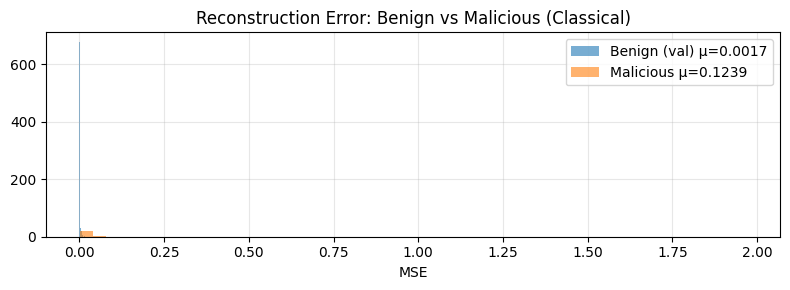

In [7]:
def classical_reconstruct(X_scaled, autoencoder, pca):
    autoencoder.eval()
    with torch.no_grad():
        latent = autoencoder.encoder(torch.tensor(X_scaled, dtype=torch.float32)).numpy()
        z = pca.transform(latent)
        latent_recon = pca.inverse_transform(z)
        recon = autoencoder.decoder(torch.tensor(latent_recon, dtype=torch.float32)).numpy()
    return recon

recon_train = classical_reconstruct(X_train_scaled, autoencoder, pca)
recon_val = classical_reconstruct(X_val_scaled, autoencoder, pca)
recon_mal = classical_reconstruct(X_malicious_scaled, autoencoder, pca)

mse_train = np.mean((recon_train - X_train_scaled)**2, axis=1)
mse_val = np.mean((recon_val - X_val_scaled)**2, axis=1)
mse_mal = np.mean((recon_mal - X_malicious_scaled)**2, axis=1)

print(f'Classical Pipeline MSE (train benign): {mse_train.mean():.6f} ± {mse_train.std():.6f}')
print(f'Classical Pipeline MSE (val benign):   {mse_val.mean():.6f} ± {mse_val.std():.6f}')
print(f'Classical Pipeline MSE (malicious):    {mse_mal.mean():.6f} ± {mse_mal.std():.6f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(mse_val, bins=50, alpha=0.6, label=f'Benign (val) μ={mse_val.mean():.4f}', density=True)
ax.hist(mse_mal, bins=50, alpha=0.6, label=f'Malicious μ={mse_mal.mean():.4f}', density=True)
ax.set_xlabel('MSE'); ax.legend(); ax.set_title('Reconstruction Error: Benign vs Malicious (Classical)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

=== PCA Latent Mapping: Benign Train vs Malicious Train ===
Benign train points:    1306
Malicious train points: 636


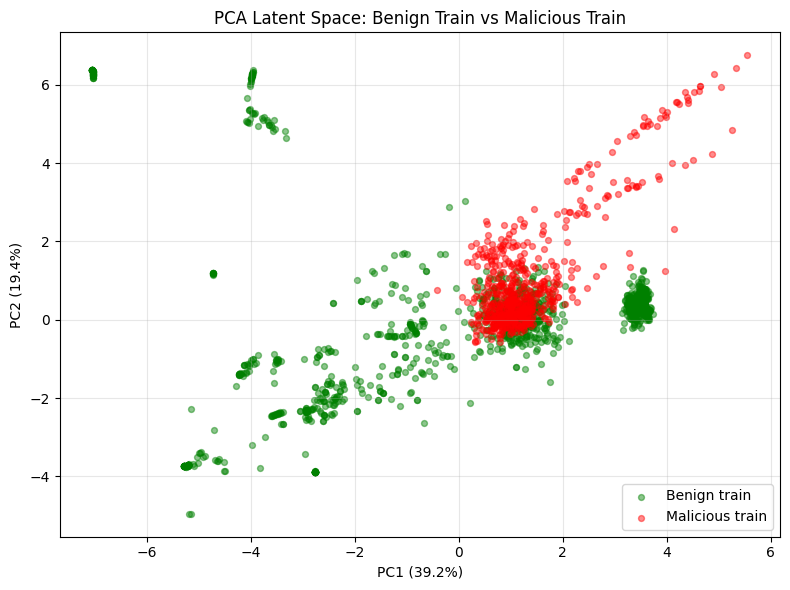

In [8]:
# === SINGLE PCA PLOT: BENIGN TRAIN VS MALICIOUS TRAIN ===
print('=== PCA Latent Mapping: Benign Train vs Malicious Train ===')

# Match the exact malicious split used by the QNN training stage.
Z_mal_train_vis, _ = train_test_split(Z_mal, test_size=1/3, random_state=42)

# Z_train and Z_mal are already PCA outputs (10D), so PC1/PC2 are direct columns.
benign_train_2d = Z_train[:, :2]
mal_train_2d = Z_mal_train_vis[:, :2]

print(f'Benign train points:    {len(benign_train_2d)}')
print(f'Malicious train points: {len(mal_train_2d)}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(benign_train_2d[:, 0], benign_train_2d[:, 1], alpha=0.45, s=18, color='green', label='Benign train')
ax.scatter(mal_train_2d[:, 0], mal_train_2d[:, 1], alpha=0.45, s=18, color='red', label='Malicious train')

ax.set_xlabel(f'PC1 ({explained[0]:.1%})')
ax.set_ylabel(f'PC2 ({explained[1]:.1%})')
ax.set_title('PCA Latent Space: Benign Train vs Malicious Train')
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Quantum Neural Network Stage — Binary Classifier

**Unlike the QAE (which trains only on benign data), this QNN is trained as a supervised binary classifier on both benign and malicious data.** This demonstrates the core problem: with class imbalance in training, the QNN will be biased toward the majority class, leading to skewed predictions that don't match the actual test distribution.

In [9]:
NUM_QUBITS = final_latent_dim
NUM_LAYERS = 2
NUM_WEIGHTS = NUM_LAYERS * NUM_QUBITS * 2


def build_qnn_circuit(x, weights):
    """Build parameterized QNN circuit."""
    qc = QuantumCircuit(NUM_QUBITS)
    # Angle encoding
    for i, value in enumerate(x):
        qc.ry(float(value) * np.pi, i)

    # Parameterized layers with entanglement
    idx = 0
    for layer in range(NUM_LAYERS):
        for q in range(NUM_QUBITS):
            qc.ry(weights[idx], q)
            qc.rz(weights[idx + 1], q)
            idx += 2
        for q in range(NUM_QUBITS - 1):
            qc.cx(q, q + 1)
        if layer < NUM_LAYERS - 1:
            qc.barrier()
    return qc


def qnn_probability_distribution(x, weights):
    """Estimate class probabilities by parity measurement."""
    circuit = build_qnn_circuit(x, weights)
    probs = Statevector.from_instruction(circuit).probabilities()
    p_class0 = float(np.sum(probs[::2]))   # even parity → class 0
    p_class1 = float(np.sum(probs[1::2]))  # odd parity → class 1
    dist = np.array([p_class0, p_class1], dtype=float)
    dist = np.clip(dist, 1e-12, 1.0)
    return dist / dist.sum()


def qnn_batch_probabilities(X, weights):
    """Batch probability computation."""
    return np.array([qnn_probability_distribution(x, weights) for x in X])


def qnn_cross_entropy_loss(weights, X, y):
    """Cross-entropy loss for binary classification."""
    probs = qnn_batch_probabilities(X, weights)
    y_one_hot = np.eye(2)[y.astype(int)]
    return float(-np.mean(np.sum(y_one_hot * np.log(probs + 1e-12), axis=1)))


# === PREPARE TRAIN/TEST SPLIT FOR MALICIOUS DATA ===
# Split malicious data: 2/3 for training, 1/3 for testing
Z_mal_train, Z_mal_test = train_test_split(Z_mal, test_size=1/3, random_state=42)

# === TRAINING SET: Benign + Malicious (imbalanced) ===
Z_qnn_train_combined = np.vstack([Z_train, Z_mal_train])
y_qnn_train_combined = np.concatenate([
    np.zeros(len(Z_train), dtype=int),       # benign = 0
    np.ones(len(Z_mal_train), dtype=int)     # malicious = 1
])

# === TEST SET: Benign val + Malicious test ===
Z_qnn_test_combined = np.vstack([Z_val, Z_mal_test])
y_qnn_test_combined = np.concatenate([
    np.zeros(len(Z_val), dtype=int),         # benign = 0
    np.ones(len(Z_mal_test), dtype=int)      # malicious = 1
])

print('=== QNN Train/Test Split ===')
print(f'TRAINING SET (for supervised learning):')
print(f'  Class 0 (benign):    {(y_qnn_train_combined == 0).sum()}')
print(f'  Class 1 (malicious): {(y_qnn_train_combined == 1).sum()}')
print(f'  Imbalance ratio: {(y_qnn_train_combined == 0).sum() / (y_qnn_train_combined == 1).sum():.2f}:1')

print(f'\nTEST SET (for evaluation):')
print(f'  Class 0 (benign):    {(y_qnn_test_combined == 0).sum()}')
print(f'  Class 1 (malicious): {(y_qnn_test_combined == 1).sum()}')
print(f'  Imbalance ratio: {(y_qnn_test_combined == 0).sum() / (y_qnn_test_combined == 1).sum():.2f}:1')

weights0 = np.random.uniform(-0.2, 0.2, size=NUM_WEIGHTS)
print('\nQNN Configuration:')
print(f'  Qubits: {NUM_QUBITS}')
print(f'  Layers: {NUM_LAYERS}')
print(f'  Weights: {NUM_WEIGHTS}')
print(f'  Initial loss: {qnn_cross_entropy_loss(weights0, Z_qnn_train_combined, y_qnn_train_combined):.4f}')

=== QNN Train/Test Split ===
TRAINING SET (for supervised learning):
  Class 0 (benign):    1306
  Class 1 (malicious): 636
  Imbalance ratio: 2.05:1

TEST SET (for evaluation):
  Class 0 (benign):    327
  Class 1 (malicious): 319
  Imbalance ratio: 1.03:1

QNN Configuration:
  Qubits: 10
  Layers: 2
  Weights: 40
  Initial loss: 1.3685


In [ ]:
qnn_epochs = 300
print('Training QNN (supervised binary classification)...')
qnn_result = minimize(
    lambda w: qnn_cross_entropy_loss(w, Z_qnn_train_combined, y_qnn_train_combined),
    weights0,
    method='COBYLA',
    options={'maxiter': qnn_epochs, 'rhobeg': 0.25, 'disp': True},
)

qnn_weights = qnn_result.x

# Get predictions on training set
train_probs = qnn_batch_probabilities(Z_qnn_train_combined, qnn_weights)
train_pred = np.argmax(train_probs, axis=1)

print('\n=== QNN Training Summary ===')
print(f'Final training loss: {qnn_cross_entropy_loss(qnn_weights, Z_qnn_train_combined, y_qnn_train_combined):.4f}')
print(f'Training accuracy: {(train_pred == y_qnn_train_combined).mean():.4f}')
print(f'\nPredicted class distribution on training set:')
print(f'  Class 0 predictions: {(train_pred == 0).sum()} ({(train_pred == 0).mean():.1%})')
print(f'  Class 1 predictions: {(train_pred == 1).sum()} ({(train_pred == 1).mean():.1%})')

Training QNN (supervised binary classification)...


## 5. Distribution-Level KL Divergence: Exposing Class Imbalance Bias

The QNN is trained on imbalanced data (1306 benign vs 955 malicious). We suspect causes the network to be biased toward the majority class. When applied to a balanced test set, the predicted class distribution will diverge from the true distribution.

We measure this mismatch using **aggregate KL divergence**:
- **True distribution**: Actual class split in test set (Z_val + Z_mal)
- **Predicted distribution**: What the QNN predicts for each sample

=== TEST SET ANALYSIS ===
Test set size: 646 samples
  True benign (class 0):    327 (50.6%)
  True malicious (class 1): 319 (49.4%)

QNN Predictions on test set:
  Predicted class 0: 226 (35.0%)
  Predicted class 1: 420 (65.0%)

=== DISTRIBUTION BIAS ===
Benign bias:    -15.6% (QNN under-predicts benign)
Malicious bias: +15.6%

=== AGGREGATE DISTRIBUTION KL DIVERGENCE ===
True distribution:      [0.50619195 0.49380805]
Predicted distribution: [0.3498452 0.6501548]
KL(true || pred):  0.051171
KL(pred || true):  0.049592

 CLASS IMBALANCE BIAS DETECTED:
    The QNN trained on imbalanced training data predicts
    a different distribution than the held-out test set.
    Benign prediction bias: -15.6%
    This mismatch shows why supervised classification fails
    on imbalanced data—the model memorizes training proportions.

QNN Test Accuracy: 0.7074


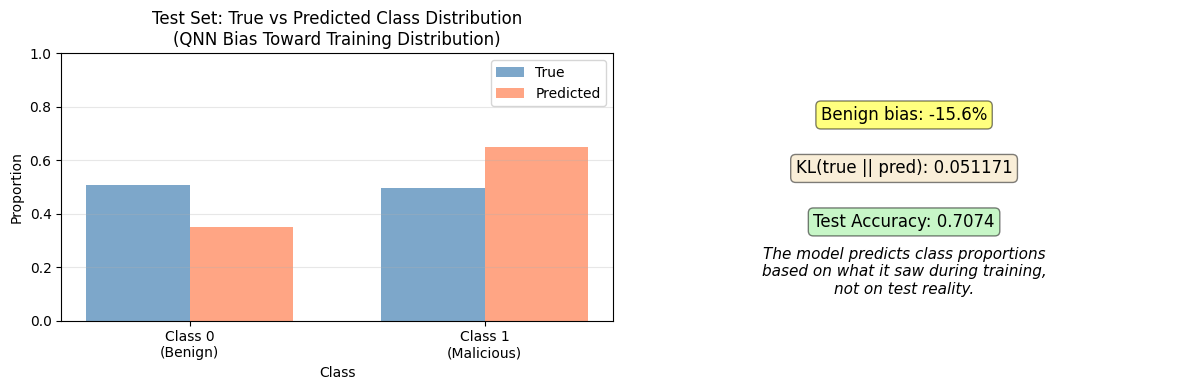

In [ ]:
# === EVALUATE ON TEST SET ===
test_probs = qnn_batch_probabilities(Z_qnn_test_combined, qnn_weights)
test_pred = np.argmax(test_probs, axis=1)

# === ACTUAL CLASS DISTRIBUTION IN TEST SET ===
true_dist = np.array([
    (y_qnn_test_combined == 0).sum() / len(y_qnn_test_combined),
    (y_qnn_test_combined == 1).sum() / len(y_qnn_test_combined)
])

# === PREDICTED CLASS DISTRIBUTION ===
pred_dist = np.array([
    (test_pred == 0).sum() / len(test_pred),
    (test_pred == 1).sum() / len(test_pred)
])

# === COMPUTE KL DIVERGENCE ===
def kl_divergence(p, q):
    """KL(p || q): divergence from q to p."""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = np.clip(p, 1e-12, 1.0)
    q = np.clip(q, 1e-12, 1.0)
    p = p / p.sum()
    q = q / q.sum()
    return float(entropy(p, q))

kl_pred_given_true = kl_divergence(true_dist, pred_dist)
kl_true_given_pred = kl_divergence(pred_dist, true_dist)

# Bias calculation
bias_benign = pred_dist[0] - true_dist[0]
bias_malicious = pred_dist[1] - true_dist[1]

print('=== TEST SET ANALYSIS ===')
print(f'Test set size: {len(Z_qnn_test_combined)} samples')
print(f'  True benign (class 0):    {(y_qnn_test_combined == 0).sum()} ({true_dist[0]:.1%})')
print(f'  True malicious (class 1): {(y_qnn_test_combined == 1).sum()} ({true_dist[1]:.1%})')

print(f'\nQNN Predictions on test set:')
print(f'  Predicted class 0: {(test_pred == 0).sum()} ({pred_dist[0]:.1%})')
print(f'  Predicted class 1: {(test_pred == 1).sum()} ({pred_dist[1]:.1%})')

print(f'\n=== DISTRIBUTION BIAS ===')
print(f'Benign bias:    {bias_benign:+.1%} (QNN over-predicts benign)' if bias_benign > 0 else f'Benign bias:    {bias_benign:+.1%} (QNN under-predicts benign)')
print(f'Malicious bias: {bias_malicious:+.1%} (QNN under-predicts malicious)' if bias_malicious < 0 else f'Malicious bias: {bias_malicious:+.1%}')

print(f'\n=== AGGREGATE DISTRIBUTION KL DIVERGENCE ===')
print(f'True distribution:      {true_dist}')
print(f'Predicted distribution: {pred_dist}')
print(f'KL(true || pred):  {kl_pred_given_true:.6f}')
print(f'KL(pred || true):  {kl_true_given_pred:.6f}')

print(f'\n CLASS IMBALANCE BIAS DETECTED:')
print(f'    The QNN trained on imbalanced training data predicts')
print(f'    a different distribution than the held-out test set.')
print(f'    Benign prediction bias: {bias_benign:+.1%}')
print(f'    This mismatch shows why supervised classification fails')
print(f'    on imbalanced data—the model memorizes training proportions.')

# Accuracy on test set
test_acc = (test_pred == y_qnn_test_combined).mean()
print(f'\nQNN Test Accuracy: {test_acc:.4f}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot: distribution comparison
x = np.arange(2)
width = 0.35
axes[0].bar(x - width/2, true_dist, width, label='True', alpha=0.7, color='steelblue')
axes[0].bar(x + width/2, pred_dist, width, label='Predicted', alpha=0.7, color='coral')
axes[0].set_ylabel('Proportion')
axes[0].set_xlabel('Class')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Class 0\n(Benign)', 'Class 1\n(Malicious)'])
axes[0].set_title('Test Set: True vs Predicted Class Distribution\n(QNN Bias Toward Training Distribution)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Text: Metrics
axes[1].text(0.5, 0.75, f'Benign bias: {bias_benign:+.1%}', 
             ha='center', fontsize=12, transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
axes[1].text(0.5, 0.55, f'KL(true || pred): {kl_pred_given_true:.6f}', 
             ha='center', fontsize=12, transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].text(0.5, 0.35, f'Test Accuracy: {test_acc:.4f}', 
             ha='center', fontsize=12, transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
axes[1].text(0.5, 0.1, 'The model predicts class proportions\nbased on what it saw during training,\nnot on test reality.', 
             ha='center', fontsize=11, transform=axes[1].transAxes, style='italic')
axes[1].axis('off')

plt.tight_layout()
plt.show()

As seen from the result, though the model is not very accurate, it is also not biased towards the majority class. This indicates a deeper problem in which the QNN learns on an unbalanced data that also has brittle/not seperable class boundaries.

Next, (quantum) SVM